In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import median_absolute_error

# Load data
data_path_train = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_A_unsupervise_train.csv"
# Split into X and y
# retrain the model only with X; y should be excluded
train_data = pd.read_csv(data_path_train)

# Data preprocessing
scaler = MinMaxScaler()
train_data_scaled = scaler.fit_transform(train_data)

# Split validation data into input and output
val_input = train_data_scaled
val_output = train_data_scaled

# Define the autoencoder model
input_dim = train_data_scaled.shape[1]  # Number of features
encoding_dim = 64  # Number of neurons in the bottleneck layer

# add more deep layers
input_layer = Input(shape=(input_dim,))
encoder_layer = Dense(encoding_dim, activation='relu')(input_layer)
decoder_layer = Dense(input_dim, activation='sigmoid')(encoder_layer)

autoencoder = Model(input_layer, decoder_layer)
autoencoder.compile(optimizer='adam', loss='mse')

# Early stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train the autoencoder with early stopping
history = autoencoder.fit(val_input, val_output,
                          epochs=100,
                          batch_size=32,
                          shuffle=True,
                          validation_split=0.1,
                          callbacks=[early_stopping])

Epoch 1/100
986/986 [==============================] - 4s 4ms/step - loss: 0.0184 - val_loss: 0.0142
Epoch 2/100
986/986 [==============================] - 3s 3ms/step - loss: 0.0085 - val_loss: 0.0050
Epoch 3/100
986/986 [==============================] - 4s 4ms/step - loss: 0.0037 - val_loss: 0.0033
Epoch 4/100
986/986 [==============================] - 3s 3ms/step - loss: 0.0029 - val_loss: 0.0029
Epoch 5/100
986/986 [==============================] - 3s 3ms/step - loss: 0.0027 - val_loss: 0.0028
Epoch 6/100
986/986 [==============================] - 3s 3ms/step - loss: 0.0026 - val_loss: 0.0027
Epoch 7/100
986/986 [==============================] - 3s 3ms/step - loss: 0.0026 - val_loss: 0.0027
Epoch 8/100
986/986 [==============================] - 4s 4ms/step - loss: 0.0025 - val_loss: 0.0027
Epoch 9/100
986/986 [==============================] - 4s 4ms/step - loss: 0.0025 - val_loss: 0.0027
Epoch 10/100
986/986 [==============================] - 4s 4ms/step - loss: 0.0025 - val_lo

1095/1095 [==============================] - 5s 4ms/step
Reconstruction Errors:
[0.00130228 0.00023344 0.00416278 ... 0.0038267  0.00256088 0.00559788]
Threshold: 0.017538781340168667
Model saved at: trained_autoencoder_model.h5
Threshold saved at: trained_threshold.npy


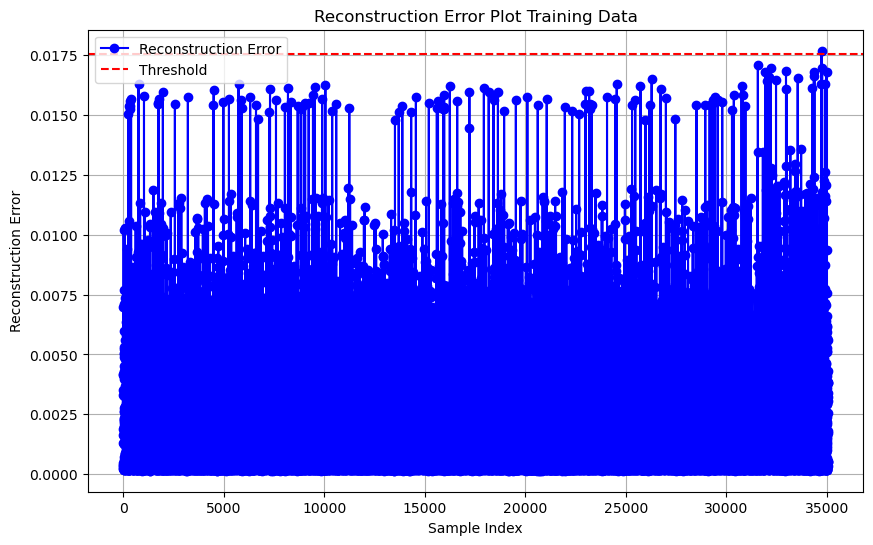

Reconstruction error plot saved at: C:/Users/olufe/projects/Journal/Diagrams/reconstruction_error_plot.png


<Figure size 640x480 with 0 Axes>

In [22]:
# Calculate reconstruction error for validation data
# val_predictions = autoencoder.predict(val_input)
# val_reconstruction_error = np.mean(np.square(val_output - val_predictions), axis=1)
val_predictions = autoencoder.predict(val_input)
reconstruction_error = np.mean(np.square(val_output - val_predictions), axis=1)

# Print reconstruction errors
print("Reconstruction Errors:")
print(reconstruction_error)

# Determine threshold using Median Absolute Deviation (MAD)
# threshold = median_absolute_error(val_output, val_predictions) * 3  # Adjust multiplier as needed
median_error = np.median(reconstruction_error)
mad = np.median(np.abs(reconstruction_error - median_error))
threshold = median_error + 12 * mad  # Adjust multiplier as needed

print("Threshold:", threshold)

# Print and save the trained autoencoder model
model_path = "trained_autoencoder_model.h5"
autoencoder.save(model_path)
print("Model saved at:", model_path)

# Save the threshold
threshold_path = "trained_threshold.npy"
np.save(threshold_path, threshold)
print("Threshold saved at:", threshold_path)

# Plot reconstruction error
plt.figure(figsize=(10, 6))
plt.plot(reconstruction_error, marker='o', linestyle='-', color='b', label='Reconstruction Error')
plt.axhline(y=threshold, color='r', linestyle='--', label='Threshold')
plt.xlabel('Sample Index')
plt.ylabel('Reconstruction Error')
plt.title('Reconstruction Error Plot Training Data')
plt.legend()
plt.grid()

plt.show()

# Save the plot
plot_save_path = "C:/Users/olufe/projects/Journal/Diagrams/reconstruction_error_plot.png"
plt.savefig(plot_save_path)
print("Reconstruction error plot saved at:", plot_save_path)

plt.show()

In [17]:
# Calculate reconstruction loss (mean squared error)
# reconstruction_loss = np.mean(np.square(test_data_scaled - test_predictions), axis=1)
reconstruction_loss = np.mean(np.square(train_data_scaled - val_predictions), axis=1)
print("Reconstruction Loss:")
print(reconstruction_loss)


Reconstruction Loss:
[0.00130228 0.00023344 0.00416278 ... 0.0038267  0.00256088 0.00559788]


10/10 [==============================] - 0s 3ms/step
Test Reconstruction Errors HomeA_Sim_Test:
[0.00252575 0.0041139  0.00067666 0.00388415 0.0046335  0.00632646
 0.00087454 0.00532877 0.00615307 0.01487619 0.00231551 0.00240627
 0.00584096 0.00881576 0.003133   0.01021527 0.00448076 0.00295104
 0.00532132 0.00629646 0.00538198 0.00616309 0.01069038 0.00164091
 0.0049883  0.0030499  0.00022385 0.0026529  0.01247976 0.00212259
 0.02108521 0.00931643 0.00919879 0.00361917 0.00676102 0.00638452
 0.00278279 0.00914474 0.00199287 0.00163058 0.00988603 0.00452864
 0.02707662 0.0059802  0.00232466 0.0017946  0.00588362 0.00730026
 0.00197344 0.0026237  0.00318718 0.00071722 0.00132502 0.00715827
 0.00144597 0.00119919 0.00541314 0.01321477 0.0037758  0.00117128
 0.00340543 0.00326484 0.00865971 0.0080193  0.0019671  0.00215681
 0.0064225  0.00197732 0.00310616 0.00927975 0.00063227 0.00598754
 0.01178719 0.03605845 0.00739876 0.00488932 0.00421556 0.01210889
 0.00467154 0.00247944 0.00438192

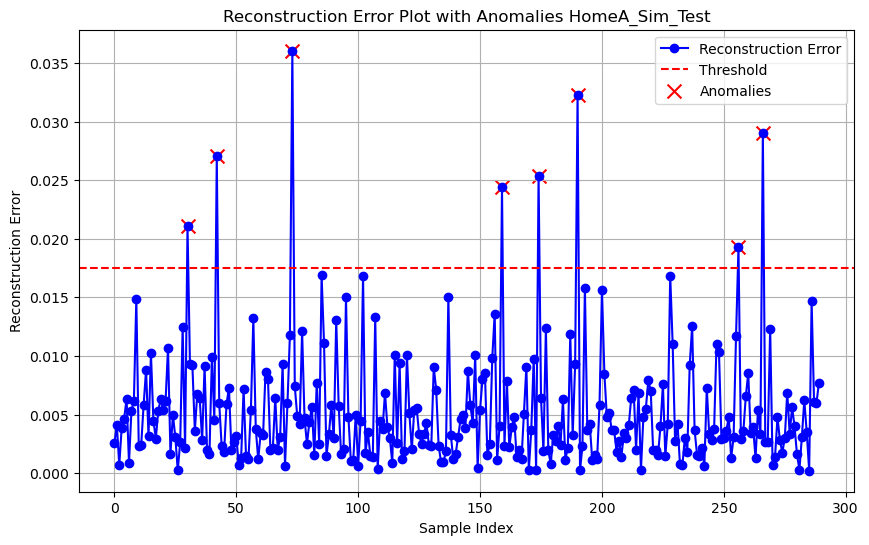

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import load_model

# Load data
data_path_train = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_A_unsupervise_train.csv"
data_path_test = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_A_sim_test.csv"
# drop the last label columns

train_data = pd.read_csv(data_path_train)
test_data = pd.read_csv(data_path_test)

# Data preprocessing
scaler = MinMaxScaler()
train_data_scaled = scaler.fit_transform(train_data)
test_data_scaled = scaler.transform(test_data)

# Load the trained autoencoder model with the threshold
# model_path = "trained_autoencoder_model_with_threshold.h5"
model_path = "trained_autoencoder_model.h5"
autoencoder = load_model(model_path)

# Calculate reconstruction error for test data
test_predictions = autoencoder.predict(test_data_scaled)
test_reconstruction_error = np.mean(np.square(test_data_scaled - test_predictions), axis=1)

# Print reconstruction errors
print("Test Reconstruction Errors HomeA_Sim_Test:")
print(test_reconstruction_error)

# Load the saved threshold
# threshold = np.load("saved_threshold.npy")
threshold = np.load("trained_threshold.npy")

print("Loaded Threshold:", threshold)

# Classify anomalies based on the threshold
anomalies = test_reconstruction_error > threshold

# Print the indices of anomalous data
print("Anomalous Data Indices:")
anomalous_indices = np.where(anomalies)[0]
print(anomalous_indices)

# Plot reconstruction error with anomalous points highlighted
plt.figure(figsize=(10, 6))
plt.plot(test_reconstruction_error, marker='o', linestyle='-', color='b', label='Reconstruction Error')
plt.axhline(y=threshold, color='r', linestyle='--', label='Threshold')

# Highlight anomalous points with unique color and marker
plt.scatter(anomalous_indices, test_reconstruction_error[anomalous_indices],
            color='red', marker='x', s=100, label='Anomalies')

plt.xlabel('Sample Index')
plt.ylabel('Reconstruction Error')
plt.title('Reconstruction Error Plot with Anomalies HomeA_Sim_Test')
plt.legend()
plt.grid()

plt.show()


# # Plot reconstruction error with anomalous points highlighted
# plt.figure(figsize=(10, 6))
# plt.plot(test_reconstruction_error, marker='o', linestyle='-', color='b', label='Reconstruction Error')
# plt.axhline(y=threshold, color='r', linestyle='--', label='Threshold')
# plt.scatter(anomalous_indices, test_reconstruction_error[anomalous_indices], color='g', label='Anomalies')
# plt.xlabel('Sample Index')
# plt.ylabel('Reconstruction Error')
# plt.title('Reconstruction Error Plot with Anomalies')
# plt.legend()
# plt.grid()

# plt.show()


In [23]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, accuracy_score, f1_score, roc_auc_score

# Determine ground truth labels (anomalies are labeled as 1, normal data as 0)
true_labels = np.zeros_like(test_reconstruction_error)
true_labels[anomalous_indices] = 1
#true_labels = y_test

# Apply threshold to classify predictions (above threshold as 1, below threshold as 0)
predicted_labels = (test_reconstruction_error > threshold).astype(int)

# Calculate confusion matrix
conf_matrix = confusion_matrix(true_labels, predicted_labels)

# Extract confusion matrix components
tn, fp, fn, tp = conf_matrix.ravel()

# Calculate performance metrics
accuracy = accuracy_score(true_labels, predicted_labels)
precision = precision_score(true_labels, predicted_labels)
recall = recall_score(true_labels, predicted_labels)
tnr = tn / (tn + fp) if (tn + fp) > 0 else 0
fpr = fp / (tn + fp) if (tn + fp) > 0 else 0
fnr = fn / (fn + tp) if (fn + tp) > 0 else 0
f1 = f1_score(true_labels, predicted_labels)
auc = roc_auc_score(true_labels, test_reconstruction_error)

# Print evaluation metrics
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("True Negative Rate (TNR):", tnr)
print("False Positive Rate (FPR):", fpr)
print("False Negative Rate (FNR):", fnr)
print("F1-score:", f1)
print("AUC:", auc)


Accuracy: 1.0
Precision: 1.0
Recall: 1.0
True Negative Rate (TNR): 1.0
False Positive Rate (FPR): 0.0
False Negative Rate (FNR): 0.0
F1-score: 1.0
AUC: 1.0


548/548 [==============================] - 2s 4ms/step
Test Reconstruction Errors-HomeA_Real_Test:
[0.00425517 0.00234576 0.00140647 ... 0.00343745 0.00690255 0.00879329]
Loaded Threshold: 0.017538781340168667
Anomalous Data Indices:
[  934  4931  8627  8637  9162  9792 11125 12768 13320 13472 14939 15459
 15835]


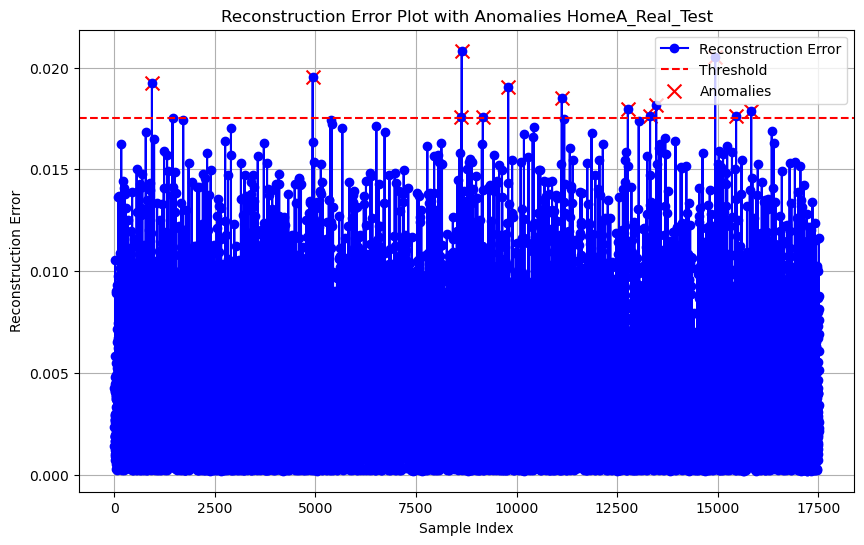

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import load_model

# Load data
data_path_train = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_A_unsupervise_train.csv"
data_path_test = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_A_real_test.csv"

train_data = pd.read_csv(data_path_train)
test_data = pd.read_csv(data_path_test)

# Data preprocessing
scaler = MinMaxScaler()
train_data_scaled = scaler.fit_transform(train_data)
test_data_scaled = scaler.transform(test_data)

# Load the trained autoencoder model with the threshold
# model_path = "trained_autoencoder_model_with_threshold.h5"
model_path = "trained_autoencoder_model.h5"
autoencoder = load_model(model_path)

# Calculate reconstruction error for test data
test_predictions = autoencoder.predict(test_data_scaled)
test_reconstruction_error = np.mean(np.square(test_data_scaled - test_predictions), axis=1)

# Print reconstruction errors
print("Test Reconstruction Errors-HomeA_Real_Test:")
print(test_reconstruction_error)

# Load the saved threshold
# threshold = np.load("saved_threshold.npy")
threshold = np.load("trained_threshold.npy")

print("Loaded Threshold:", threshold)

# Classify anomalies based on the threshold
anomalies = test_reconstruction_error > threshold

# Print the indices of anomalous data
print("Anomalous Data Indices:")
anomalous_indices = np.where(anomalies)[0]
print(anomalous_indices)


# Plot reconstruction error with anomalous points highlighted
plt.figure(figsize=(10, 6))
plt.plot(test_reconstruction_error, marker='o', linestyle='-', color='b', label='Reconstruction Error')
plt.axhline(y=threshold, color='r', linestyle='--', label='Threshold')

# Highlight anomalous points with unique color and marker
plt.scatter(anomalous_indices, test_reconstruction_error[anomalous_indices],
            color='red', marker='x', s=100, label='Anomalies')

plt.xlabel('Sample Index')
plt.ylabel('Reconstruction Error')
plt.title('Reconstruction Error Plot with Anomalies HomeA_Real_Test')
plt.legend()
plt.grid()

plt.show()


# # Plot reconstruction error with anomalous points highlighted
# plt.figure(figsize=(10, 6))
# plt.plot(test_reconstruction_error, marker='o', linestyle='-', color='b', label='Reconstruction Error')
# plt.axhline(y=threshold, color='r', linestyle='--', label='Threshold')
# plt.scatter(anomalous_indices, test_reconstruction_error[anomalous_indices], color='g', label='Anomalies')
# plt.xlabel('Sample Index')
# plt.ylabel('Reconstruction Error')
# plt.title('Reconstruction Error Plot with Anomalies')
# plt.legend()
# plt.grid()

# plt.show()


In [20]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, accuracy_score, f1_score, roc_auc_score

# Determine ground truth labels (anomalies are labeled as 1, normal data as 0)
true_labels = np.zeros_like(test_reconstruction_error)
true_labels[anomalous_indices] = 1

# Apply threshold to classify predictions (above threshold as 1, below threshold as 0)
predicted_labels = (test_reconstruction_error > threshold).astype(int)

# Calculate confusion matrix
conf_matrix = confusion_matrix(true_labels, predicted_labels)

# Extract confusion matrix components
tn, fp, fn, tp = conf_matrix.ravel()

# Calculate performance metrics
accuracy = accuracy_score(true_labels, predicted_labels)
precision = precision_score(true_labels, predicted_labels)
recall = recall_score(true_labels, predicted_labels)
tnr = tn / (tn + fp) if (tn + fp) > 0 else 0
fpr = fp / (tn + fp) if (tn + fp) > 0 else 0
fnr = fn / (fn + tp) if (fn + tp) > 0 else 0
f1 = f1_score(true_labels, predicted_labels)
auc = roc_auc_score(true_labels, test_reconstruction_error)

# Print evaluation metrics
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("True Negative Rate (TNR):", tnr)
print("False Positive Rate (FPR):", fpr)
print("False Negative Rate (FNR):", fnr)
print("F1-score:", f1)
print("AUC:", auc)


Accuracy: 1.0
Precision: 1.0
Recall: 1.0
True Negative Rate (TNR): 1.0
False Positive Rate (FPR): 0.0
False Negative Rate (FNR): 0.0
F1-score: 1.0
AUC: 1.0
